In [8]:
import pandas as pd
import matplotlib.pyplot as plt
from tqdm import tqdm 

import torch
from torch import nn
import torchvision
import torchvision.transforms as transforms

import numpy as np
import random
np.random.seed(0)
torch.manual_seed(0)
random.seed(0)


# Data

In [9]:

transform = transforms.ToTensor()

training_set = torchvision.datasets.FashionMNIST('./data', train=True, transform=transform, download=True)
validation_set = torchvision.datasets.FashionMNIST('./data', train=False, transform=transform, download=True)

training_loader = torch.utils.data.DataLoader(training_set, batch_size=32, shuffle=True)
validation_loader = torch.utils.data.DataLoader(validation_set, batch_size=128, shuffle=False)

classes = ('T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
        'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle Boot')


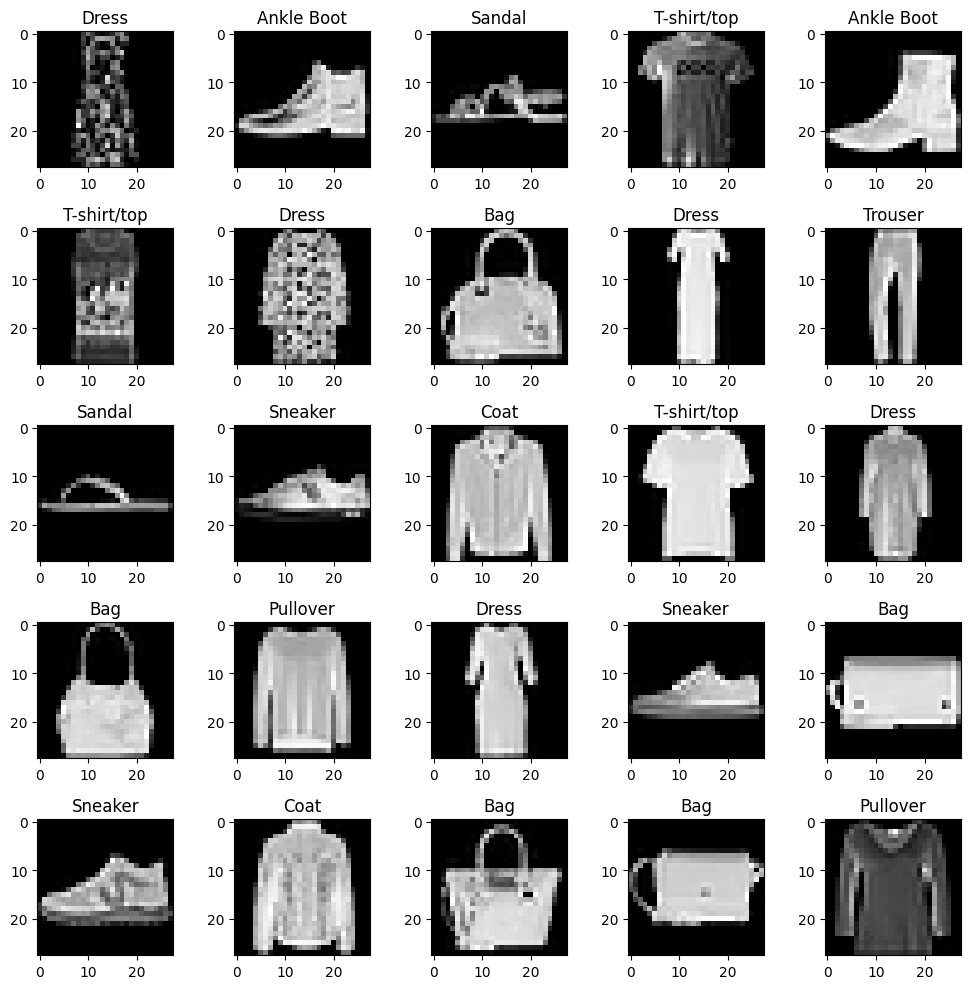

In [10]:
batch = next(iter(training_loader))
plt.figure(figsize=(10, 10))
for i, (image, label) in enumerate(zip(*batch)):
    if i > 24:
        break
    plt.subplot(5, 5, i + 1)
    plt.imshow(image[0], cmap="gray")
    plt.title(classes[label])

plt.tight_layout()

# Exercise

You are required to train an MLP on the Fashion MNIST dataset. For this task, you must define the following:

* The objective function
* The model architecture
* The optimizer
* The training loop

You will train three MLP models, each with different hyperparameters. You must vary at least two of the following aspects between the models:

* Number of layers
* Number of neurons
* Activation function
* Optimizer


## Deliverables
* The complete code
* Learning curves for the three MLP models
* Table summarizing the changes in the hyperparameters and the performance of the models on the train and test sets. 
* A write-up analyzing how your choices impacted the results.

In [11]:
training_set[0][0].shape

torch.Size([1, 28, 28])

In [12]:
validation_loader.batch_size

128

In [13]:
class NN1(nn.Module):
    def __init__(self, activation, input_size=28*28, output_size=10):
        super(NN1, self).__init__()
        self.activation = activation
        self.l1 = nn.Linear(input_size, 64)
        self.l2 = nn.Linear(64, 128)
        self.l3 = nn.Linear(128, 256)
        self.l4 = nn.Linear(256,64)
        self.l5 = nn.Linear(64, output_size)
    def forward(self, x):
        x = self.activation(self.l1(x))
        x = self.activation(self.l2(x))
        x = self.activation(self.l3(x))
        x = self.activation(self.l4(x))
        x = self.l5(x)
        return x

In [14]:
def train(model, optimizer):
    criterion = nn.CrossEntropyLoss()
    epochs = 10
    epoch_losses = []
    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0
        Acc = []
        batch_losses = []
        for images, labels in training_loader:
            optimizer.zero_grad()
            images = images.view(-1, 28*28)
            output = model(images)
            loss = criterion(output, labels)
            loss.backward()
            optimizer.step()
            batch_losses.append(loss.item())
            predicted = torch.argmax(output, dim=1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
            Acc.append(100 * correct / total)
        epoch_losses.append(np.mean(batch_losses))
        print(f"Epoch {epoch+1}/{epochs}, Loss: {np.mean(batch_losses)}, Accuracy: {100 * correct / total}")
    return epoch_losses, Acc

def eval(model):
    model.eval()
    right_preds = 0
    total_preds = 0
    with torch.no_grad():
        for images, labels in validation_loader:
            images = images.view(-1, 28*28)
            output = model(images)
            predicted = torch.argmax(output, dim=1)
            total_preds += labels.size(0)
            right_preds += (predicted == labels).sum().item()
    return 100 * (right_preds / total_preds)          

In [15]:
model1 = NN1(nn.ELU())
model2 = NN1(nn.SiLU())
model3 = NN1(nn.GELU())
optimizer1= torch.optim.Adam(model1.parameters(), lr=1e-3)
optimizer2= torch.optim.SGD(model2.parameters(), lr=1e-3)
optimizer3= torch.optim.RMSprop(model3.parameters(), lr=1e-3)

In [16]:
losses1, train1_acc = train(model1, optimizer1)
valid1_acc = eval(model1)

Epoch 1/10, Loss: 0.5137120034694672, Accuracy: 81.19
Epoch 2/10, Loss: 0.3934880660533905, Accuracy: 85.56833333333333
Epoch 3/10, Loss: 0.3590712514380614, Accuracy: 86.795
Epoch 4/10, Loss: 0.3358382590631644, Accuracy: 87.61
Epoch 5/10, Loss: 0.3185369438846906, Accuracy: 88.255
Epoch 6/10, Loss: 0.3023802830974261, Accuracy: 88.70833333333333
Epoch 7/10, Loss: 0.2902971036314964, Accuracy: 89.275
Epoch 8/10, Loss: 0.27673431585232416, Accuracy: 89.68
Epoch 9/10, Loss: 0.2669204967359702, Accuracy: 90.01
Epoch 10/10, Loss: 0.25943037520051004, Accuracy: 90.205


In [18]:
losses2, train2_acc = train(model2, optimizer2)
valid2_acc = eval(model2)

Epoch 1/10, Loss: 2.3038040877024333, Accuracy: 10.0
Epoch 2/10, Loss: 2.302675910313924, Accuracy: 10.0
Epoch 3/10, Loss: 2.3017168983459473, Accuracy: 10.0
Epoch 4/10, Loss: 2.3008018145243327, Accuracy: 10.0
Epoch 5/10, Loss: 2.2998199771881103, Accuracy: 10.0
Epoch 6/10, Loss: 2.2986430502573647, Accuracy: 9.998333333333333
Epoch 7/10, Loss: 2.297091115697225, Accuracy: 10.331666666666667
Epoch 8/10, Loss: 2.294861376317342, Accuracy: 13.068333333333333
Epoch 9/10, Loss: 2.2913577598571777, Accuracy: 18.385
Epoch 10/10, Loss: 2.285229002380371, Accuracy: 19.345


In [19]:
losses3, train3_acc = train(model3, optimizer3)
valid3_acc = eval(model3)

Epoch 1/10, Loss: 0.5100329710682233, Accuracy: 81.01333333333334
Epoch 2/10, Loss: 0.37201765291492145, Accuracy: 86.23
Epoch 3/10, Loss: 0.33675149054725967, Accuracy: 87.575
Epoch 4/10, Loss: 0.3119531462550163, Accuracy: 88.44833333333334
Epoch 5/10, Loss: 0.29432160745461783, Accuracy: 89.01333333333334
Epoch 6/10, Loss: 0.27915948476890723, Accuracy: 89.41833333333334
Epoch 7/10, Loss: 0.26570389296114444, Accuracy: 90.00333333333333
Epoch 8/10, Loss: 0.25668167040348056, Accuracy: 90.24666666666667
Epoch 9/10, Loss: 0.24454532186985015, Accuracy: 90.86166666666666
Epoch 10/10, Loss: 0.2371580295463403, Accuracy: 91.095


In [20]:
print(f"trainAcc: {train1_acc[-1]}, ValidAcc: {valid1_acc}")
print(f"trainAcc: {train2_acc[-1]}, ValidAcc: {valid2_acc}")
print(f"trainAcc: {train3_acc[-1]}, ValidAcc: {valid3_acc}")

trainAcc: 90.205, ValidAcc: 87.42999999999999
trainAcc: 19.345, ValidAcc: 19.57
trainAcc: 91.095, ValidAcc: 88.24


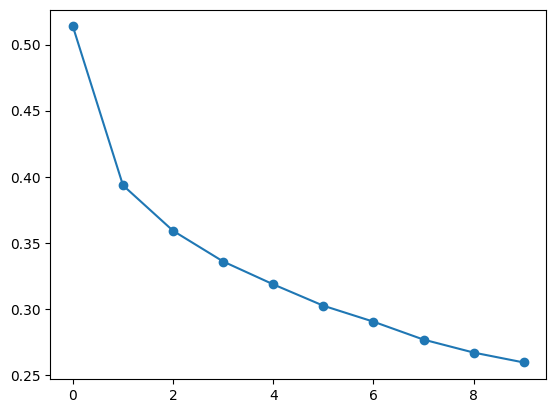

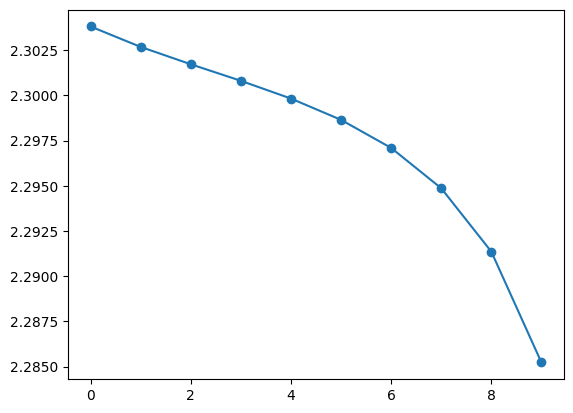

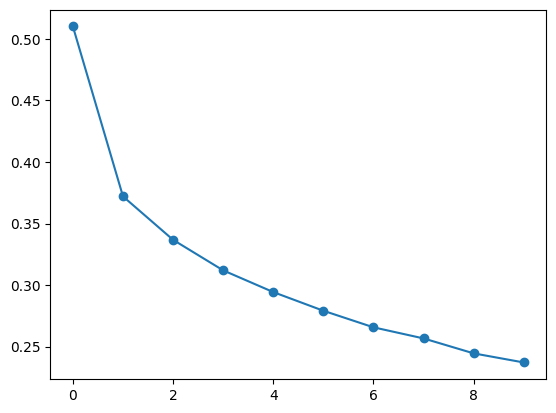

In [21]:
import matplotlib.pyplot as plt
plt.plot(losses1, label="model1 loss", marker='o')
plt.show()
plt.plot(losses2, label="model2 loss", marker='o')
plt.show()
plt.plot(losses3, label="model3 loss", marker='o')
plt.show()

In [22]:
import pandas as pd
results = pd.DataFrame(
    {
        "model": ["model1", "model2", "model3"],
        "Activation": ["ELU", "SiLU", "GELU"],
        "Optimizer": ["Adam", "SGD", "RMSprop"],
        "trainAcc": [train1_acc[-1], train2_acc[-1], train3_acc[-1]],
        "validAcc": [valid1_acc, valid2_acc, valid3_acc],
    }
)
results

,model,Activation,Optimizer,trainAcc,validAcc
0,model1,ELU,Adam,90.205,87.43
1,model2,SiLU,SGD,19.345,19.57
2,model3,GELU,RMSprop,91.095,88.24


In [44]:
model1.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 0.2011, -0.0735, -0.2904,  ..., -0.0171, -0.3832, -0.0988],
                      [ 0.0810, -0.0074, -0.2634,  ..., -0.3539, -0.0306,  0.0536],
                      [-0.1024,  0.0774,  0.0884,  ...,  0.2273,  0.1557,  0.1520],
                      ...,
                      [ 0.0370,  0.1217,  0.1420,  ...,  0.3365,  0.1247,  0.1047],
                      [-0.2879, -0.2515, -0.2852,  ..., -0.5237, -0.3256, -0.5182],
                      [-0.2929, -0.2626, -0.4308,  ..., -0.0710,  0.2703, -0.3635]])),
             ('l1.bias',
              tensor([ 0.0617,  0.0275,  0.2489,  0.0720,  0.0084, -0.4318,  0.1298,  0.1008,
                      -0.0838,  0.0507, -0.0989,  0.1240,  0.0509, -0.2055,  0.0855, -0.1465,
                       0.0025, -0.0086,  0.0449, -0.1740, -0.1220, -0.1558, -0.1381, -0.3389,
                      -0.0154, -0.1832,  0.0150,  0.1083, -0.1077,  0.2440, -0.1404,  0.1062,
                       0.0268, -0.3081

In [45]:
model2.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 0.0109,  0.0017,  0.0306,  ...,  0.0029,  0.0118, -0.0085],
                      [ 0.0320,  0.0156,  0.0247,  ...,  0.0030, -0.0171,  0.0182],
                      [ 0.0186, -0.0265,  0.0006,  ...,  0.0292, -0.0069,  0.0077],
                      ...,
                      [-0.0348, -0.0099, -0.0283,  ...,  0.0081, -0.0053, -0.0094],
                      [ 0.0154,  0.0281, -0.0084,  ..., -0.0073,  0.0063,  0.0240],
                      [ 0.0310,  0.0238,  0.0202,  ...,  0.0347, -0.0327, -0.0238]])),
             ('l1.bias',
              tensor([-3.1915e-04,  1.6594e-02,  2.4714e-02, -3.2074e-02,  2.5826e-02,
                       1.1464e-02,  3.3539e-04, -8.6978e-03,  2.3128e-02,  2.7839e-03,
                       8.5081e-03, -4.4586e-03,  2.9581e-02,  3.5187e-02,  2.2632e-02,
                       5.2421e-03,  1.7101e-02, -2.8942e-02, -2.0851e-02,  1.0189e-03,
                      -3.2993e-02, -1.4978e-02, -9.0398e-03, -2.68

In [46]:
model3.state_dict()

OrderedDict([('l1.weight',
              tensor([[ 1.2572e-01,  1.1831e-01, -1.9096e-01,  ...,  1.2483e-01,
                        1.0922e-01,  3.0477e-02],
                      [ 1.7517e-01,  7.4809e-02, -1.3673e-02,  ...,  1.6570e-01,
                        1.7824e-01,  5.5565e-02],
                      [-6.5565e-06, -3.7622e-02, -8.2172e-02,  ...,  1.0527e-01,
                        2.7950e-02,  1.4356e-01],
                      ...,
                      [-6.6928e-02, -1.5686e-02, -8.5670e-02,  ..., -1.0417e-01,
                        8.1648e-02,  8.1157e-02],
                      [-1.6061e-01, -1.8572e-01, -3.3065e-01,  ..., -3.2688e-01,
                       -2.9906e-01, -1.5507e-01],
                      [-1.4624e-01, -2.0505e-01, -1.0822e-01,  ..., -7.1411e-02,
                       -1.7034e-01, -3.0862e-01]])),
             ('l1.bias',
              tensor([ 0.1285, -0.1043, -0.1678,  0.1187, -0.0153, -0.0089,  0.0276, -0.0394,
                      -0.1510, -0.1123

## testing silu with adam to see if issue in activation function or the optimizer it self

In [54]:
model4 = NN1(nn.SiLU())
optimizer4 = torch.optim.Adam(model4.parameters(), lr=1e-3)
losses4, train4_acc = train(model4, optimizer4)
valid4_acc = eval(model4)
print(f"trainAcc: {train4_acc[-1]}, ValidAcc: {valid4_acc}")

Epoch 1/10, Loss: 0.5375310147881508, Accuracy: 80.07166666666667
Epoch 2/10, Loss: 0.3886524611949921, Accuracy: 85.59666666666666
Epoch 3/10, Loss: 0.3459529027183851, Accuracy: 87.10666666666667
Epoch 4/10, Loss: 0.31717906100153925, Accuracy: 88.285
Epoch 5/10, Loss: 0.29698127644459404, Accuracy: 88.96333333333334
Epoch 6/10, Loss: 0.2819066809266806, Accuracy: 89.44666666666667
Epoch 7/10, Loss: 0.2675664910246929, Accuracy: 90.04833333333333
Epoch 8/10, Loss: 0.2557581437706947, Accuracy: 90.29333333333334
Epoch 9/10, Loss: 0.24438317967057227, Accuracy: 90.86333333333333
Epoch 10/10, Loss: 0.2326402520030737, Accuracy: 91.19333333333333
trainAcc: 91.19333333333333, ValidAcc: 87.97


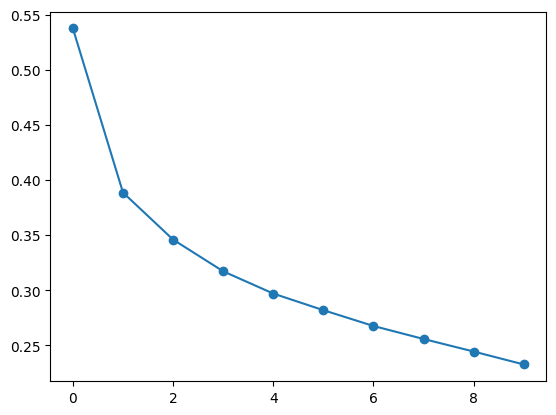

In [55]:
plt.plot(losses4, label="model4 loss", marker='o')
plt.show()

In [56]:
model5 = NN1(nn.SiLU())
opt5 = torch.optim.SGD(model5.parameters(), lr=1e-1)
losses5, train5_acc = train(model5, opt5)
valid5_acc = eval(model5)
print(f"trainAcc: {train5_acc[-1]}, ValidAcc: {valid5_acc}")

Epoch 1/10, Loss: 1.0328071813265483, Accuracy: 60.608333333333334
Epoch 2/10, Loss: 0.4775143075625102, Accuracy: 82.56
Epoch 3/10, Loss: 0.41468191885153455, Accuracy: 84.74666666666667
Epoch 4/10, Loss: 0.3804504793008169, Accuracy: 85.73
Epoch 5/10, Loss: 0.35771291844646136, Accuracy: 86.64666666666666
Epoch 6/10, Loss: 0.3393973347286383, Accuracy: 87.38
Epoch 7/10, Loss: 0.3239103096187115, Accuracy: 87.85333333333334
Epoch 8/10, Loss: 0.31186503544648486, Accuracy: 88.42666666666666
Epoch 9/10, Loss: 0.3029327472150326, Accuracy: 88.76
Epoch 10/10, Loss: 0.29289721951285996, Accuracy: 88.97333333333333
trainAcc: 88.97333333333333, ValidAcc: 86.83


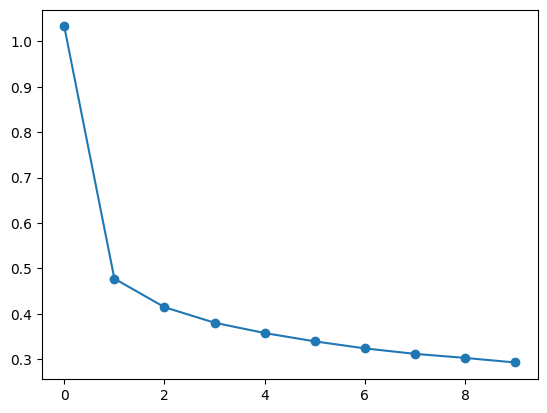

In [57]:
plt.plot(losses5, label="model5 loss", marker='o')
plt.show()

## I played with the optimizer and activation function turns out SGD is really bad with low lr but when i increased lr it did well
## performance of the 2 other optimizers ADAM and RMSprop with GILU or ELU is decent related to only small numbers of epochs, model didnt overfit
## silu with ADAM is doing well

## for fun testing

In [65]:
model6 = NN1(nn.CELU())
opt6 = torch.optim.NAdam(model6.parameters(), lr=1e-3)
losses6, train6_acc = train(model6, opt6)
valid6_acc = eval(model6)
print(f"trainAcc: {train6_acc[-1]}, ValidAcc: {valid6_acc}")

Epoch 1/10, Loss: 0.5099350875933965, Accuracy: 81.32833333333333
Epoch 2/10, Loss: 0.38176072794596355, Accuracy: 85.98
Epoch 3/10, Loss: 0.34462494086821877, Accuracy: 87.36166666666666
Epoch 4/10, Loss: 0.3214060092310111, Accuracy: 88.06166666666667
Epoch 5/10, Loss: 0.3025808241784573, Accuracy: 88.69833333333334
Epoch 6/10, Loss: 0.290680796311299, Accuracy: 89.18166666666667
Epoch 7/10, Loss: 0.27802259175380073, Accuracy: 89.61833333333334
Epoch 8/10, Loss: 0.26673894337018333, Accuracy: 90.045
Epoch 9/10, Loss: 0.25612354357043904, Accuracy: 90.265
Epoch 10/10, Loss: 0.24911388476888338, Accuracy: 90.59333333333333
trainAcc: 90.59333333333333, ValidAcc: 88.08


In [66]:
model7 = NN1(nn.Dropout())
opt7 = torch.optim.AdamW(model7.parameters(), lr=1e-3)
losses7, train7_acc = train(model7, opt7)
valid7_acc = eval(model7)

Epoch 1/10, Loss: 0.8591788886070252, Accuracy: 69.45
Epoch 2/10, Loss: 0.7184754078308742, Accuracy: 75.36666666666666
Epoch 3/10, Loss: 0.6884393250544866, Accuracy: 76.48
Epoch 4/10, Loss: 0.670167262283961, Accuracy: 77.36666666666666
Epoch 5/10, Loss: 0.6643197558641434, Accuracy: 77.48833333333333
Epoch 6/10, Loss: 0.6540689115842183, Accuracy: 77.835
Epoch 7/10, Loss: 0.6553565545241038, Accuracy: 77.73166666666667
Epoch 8/10, Loss: 0.6498040760676066, Accuracy: 78.14666666666666
Epoch 9/10, Loss: 0.6434240719795227, Accuracy: 78.31
Epoch 10/10, Loss: 0.6408490288734436, Accuracy: 78.315


In [ ]:
print(f"trainAcc: {train6_acc[-1]}, ValidAcc: {valid6_acc}")

trainAcc: 90.59333333333333, ValidAcc: 88.08


: 